In [1]:
import torch # pytorch kutuphanesi, tensor islemleri
import torch.nn as nn # yapay sinir agi katmanlarini tanimlamak icin kullan
import torch.optim as optim # sinir agi agirlik degerlerini guncellemek icin kullanilir
import torchvision # goruntu isleme ve pre-defined(daha once olusturulmus) modelleri icerir
import torchvision.transforms as transforms # goruntu donusumleri yapmak
import matplotlib.pyplot as plt # goruntuleri gorsellestirmek icin kullanilir


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else"cpu")

In [3]:
def get_data_loaders(batch_size=64): # her iterasyonda islenecek veri miktari
    transform = transforms.Compose([
        transforms.ToTensor(), # goruntuyu tensore cevirir ve 0-255 -> 0-1 olceklendir
        transforms.Normalize((0.5,), (0.5,)) # piksel degerlerini -1 ile 1 arasina olcekler
    ])

    # mnist veri setini indir ve egitim test kumelerini olustur.
    train_set = torchvision.datasets.MNIST(root= "./data", train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root= "./data", train=False, download=True, transform=transform)

    # pytorch veri yükleyicisini olustur
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

train_loader, test_loader = get_data_loaders()

In [4]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

60000
10000


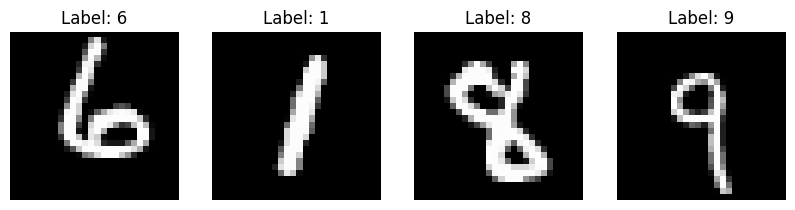

In [5]:
# data visualization
from tkinter import Label

from matplotlib import axes


def visualize_samples(loader, n):
    images, labels = next(iter(loader)) # ilk batch den goruntu ve etiketleri alalim
    fig, axes = plt.subplots(1, n, figsize=(10,5)) # n farkli goruntu icin gorsellestirme alani
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap = "gray") # gorseli gri tonlamali olarak goster
        axes[i].set_title(f"Label: {labels[i].item()}") # goruntuye ait sinif etiketini baslik olarak yaz
        axes[i].axis("off") # eksenleri gizle
    plt.show()

visualize_samples(train_loader, 4)

In [6]:
# %% define ann model
# yapay sinir agi class
class NeuralNetwork(nn.Module): # pytorchun nn.module sinifindan miras alıyorum
    def __init__(self):
        super(NeuralNetwork, self).__init__()

        self.flatten = nn.Flatten() # elimizde bulunan goruntuleri(2D) vektor haline cevirelim(1D) -> 28*28 =784

        self.fc1 = nn.Linear(28*28, 128) # ilk tam bagli katmani olustur: 784 = input size, 128 = output size

        self.relu = nn.ReLU() # aktivasyon fonksiyonu olustur

        self.fc2 = nn.Linear(128, 64) # ikinci tam bagli katmani olustur: 128 = input size, 64 = output size

        self.fc3 = nn.Linear(64, 10) # cikti katmani olustur: 64 = input size, 10 = output size (0-9 etiketleri)

    def forward(self, x): # forward propagation: ileri yayilim, giris olarak x = goruntu alsin 

        x = self.flatten(x) # initial x = 28*28 lik bir goruntu -> duzlestir 784 vektor haline getir
        x = self.fc1(x) # birinci bagli katman
        x = self.relu(x) # aktivasyon fonksiyonu 
        x = self.fc2(x) # ikinci bagli katman
        x = self.relu(x) # aktivasyon fonksiyonu
        x = self.fc3(x) # output katmani

        return x # modelimizin ciktisini return edelim   
        

# create model and compile

model = NeuralNetwork().to(device)

# kayip fonksiyonu ve optimizasyon algoritmasini belirle
define_loss_and_optimizer = lambda model: (
    nn.CrossEntropyLoss(), # multi class classification problems loss function
    optim.Adam(model.parameters(), lr=0.001)
)

criterion, optimizer = define_loss_and_optimizer(model)

Epoch 1/5, Loss: 0.408
Epoch 2/5, Loss: 0.201
Epoch 3/5, Loss: 0.149
Epoch 4/5, Loss: 0.121
Epoch 5/5, Loss: 0.102


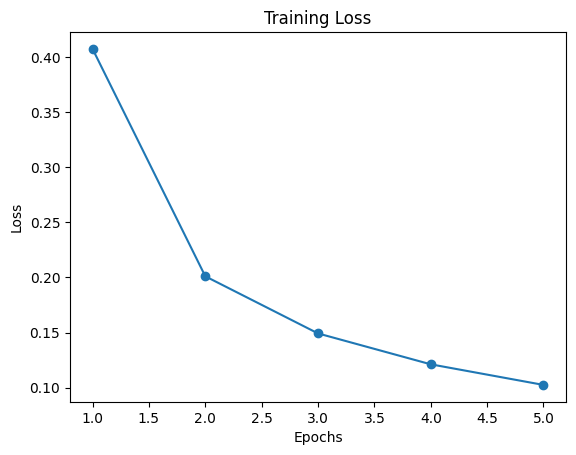

In [7]:
# %% train
def train_model(model, train_loader, criterion, optimizer, epochs = 10):

    model.train() # modelimizi egitim moduna alalım
    train_losses = [] # her bir epoch sonucunda elde edilen loss değerlerini saklamak için bir liste

    for epoch in range(epochs): # belirtilen epoch sayisi kadar egitim yapalim
        total_loss = 0 # toplam kayip degeri

        for images, labels in train_loader: # tum egitim verileri uzerinde iterasyon gerceklestir
            images, labels = images.to(device), labels.to(device) # verileri cihaza tasi

            optimizer.zero_grad() # gradyanlari sifirla
            predictions = model(images) # modeli uygula, forward pro.
            loss = criterion(predictions, labels) # loss hesaplama -> y_prediction ile y_real
            loss.backward() # geri yayilim yani gradyan hesaplama
            optimizer.step() # update weights (agirliklari guncelle)

            total_loss = total_loss + loss.item()

        avg_loss = total_loss / len(train_loader) # ortalama kayip hesaplama
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.3f}")

    # loss graph
    plt.figure()
    plt.plot(range(1, epochs + 1), train_losses, marker = "o", linestyle = "-", label = "Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

train_model(model, train_loader, criterion, optimizer, epochs=5)

In [8]:
# %% test
def test_model(model, test_loader):
    model.eval() # modelimizi test moduna alalım
    correct = 0 # dogru tahmin sayisi
    total = 0 # toplam tahmin sayisi

    with torch.no_grad(): # gradient hesaplama islemini engelle
        for images, labels in test_loader: # test veri kumesini donguye al
            images, labels = images.to(device), labels.to(device) # verileri cihaza tasi
            predictions = model(images)
            _, predicted = torch.max(predictions, 1) # en yuksek olasilikli sinifin etiketini bul

            total += labels.size(0) # toplam veri sayisini guncelle
            correct += (predicted == labels).sum().item() # dogru tahminleri say

    print(f"Test Accuracy: {100*correct/total:.3f}%")

test_model(model, test_loader)

Test Accuracy: 96.990%


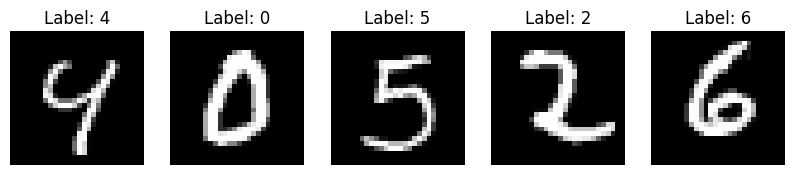

Epoch 1/10, Loss: 0.386
Epoch 2/10, Loss: 0.183
Epoch 3/10, Loss: 0.133
Epoch 4/10, Loss: 0.110
Epoch 5/10, Loss: 0.094
Epoch 6/10, Loss: 0.082
Epoch 7/10, Loss: 0.075
Epoch 8/10, Loss: 0.067
Epoch 9/10, Loss: 0.061
Epoch 10/10, Loss: 0.054


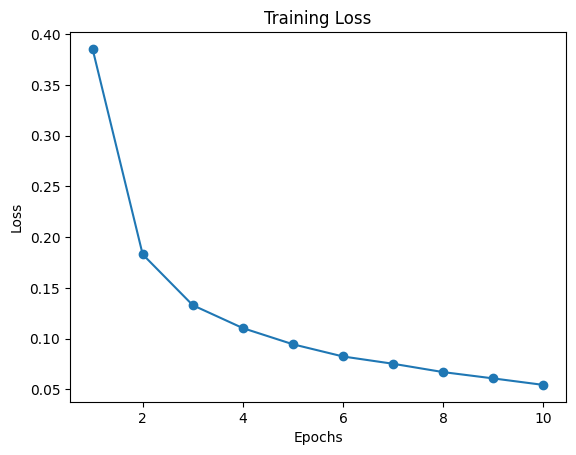

Test Accuracy: 97.040%


In [9]:
# %% main

if __name__ == "__main__":
    train_loader, test_loader = get_data_loaders() # veri yükleyicilerini al
    visualize_samples(train_loader, 5)
    model = NeuralNetwork().to(device)
    criterion, optimizer = define_loss_and_optimizer(model)
    train_model(model, train_loader, criterion, optimizer)
    test_model(model, test_loader)